In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Model # Решает NameError
from torch.utils.data import DataLoader, TensorDataset


In [4]:
(x_train_raw, y_train_raw), (x_test_raw, y_test_raw) = keras.datasets.fashion_mnist.load_data()
print(f"Данные загружены. Обучающая выборка: {x_train_raw.shape}")

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Данные загружены. Обучающая выборка: (60000, 28, 28)


In [5]:
x_train = x_train_raw / 255.0
x_test = x_test_raw / 255.0

In [6]:
x_train_k = x_train.reshape(-1, 28, 28, 1)
x_test_k = x_test.reshape(-1, 28, 28, 1)

In [7]:
inputs = keras.Input(shape=(28, 28, 1))
x = keras.layers.Conv2D(6, (3, 3), padding='same', activation='relu')(inputs)
conv_output = x
x = keras.layers.MaxPooling2D((2, 2))(x)
x = keras.layers.Flatten()(x)
outputs = keras.layers.Dense(10, activation='softmax')(x)


In [8]:
model_k = Model(inputs=inputs, outputs=outputs)
model_k.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [9]:
model_k

<Functional name=functional, built=True>

In [10]:
model_k.fit(x_train_k, y_train_raw, epochs=5, batch_size=64, verbose=1)

Epoch 1/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 21s 21ms/step - accuracy: 0.7398 - loss: 0.8137
Epoch 2/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 20s 22ms/step - accuracy: 0.8615 - loss: 0.3981
Epoch 3/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 20s 21ms/step - accuracy: 0.8757 - loss: 0.3534
Epoch 4/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 21s 23ms/step - accuracy: 0.8809 - loss: 0.3333
Epoch 5/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 19s 20ms/step - accuracy: 0.8882 - loss: 0.3164


In [11]:
def upscale_to_128x128(img):
    scale = 128 // img.shape[0]
    return img.repeat(scale, axis=0).repeat(scale, axis=1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step


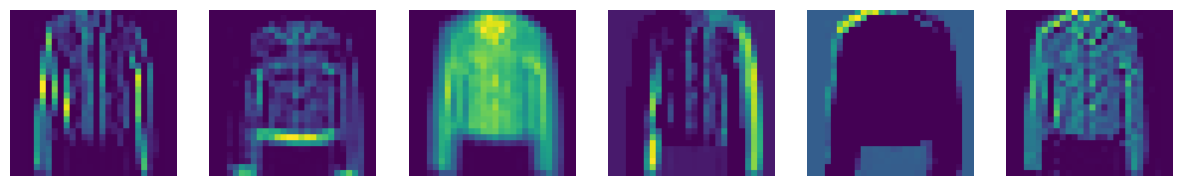

In [12]:
def visualize_keras(idx):
    img = np.expand_dims(x_test[idx], axis=0)
    img = np.expand_dims(img, axis=-1)

    activation_model = Model(inputs=model_k.input, outputs=conv_output)
    activations = activation_model.predict(img, verbose=1)

    fig, axes = plt.subplots(1, 6, figsize=(15, 3))
    for i in range(6):
        k_map = upscale_to_128x128(activations[0, :, :, i])
        axes[i].imshow(k_map, cmap='viridis')
        axes[i].axis('off')
    plt.show()

visualize_keras(10)

In [13]:
x_train_p = torch.FloatTensor(x_train.copy()).unsqueeze(1)
y_train_p = torch.LongTensor(y_train_raw.copy())
x_test_p = torch.FloatTensor(x_test.copy()).unsqueeze(1)
y_test_p = torch.LongTensor(y_test_raw.copy())

In [14]:
train_loader = DataLoader(TensorDataset(x_train_p, y_train_p), batch_size=64, shuffle=True)


In [15]:
class PyTorchModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 6, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc = nn.Linear(6 * 14 * 14, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = x.view(-1, 6 * 14 * 14)
        return self.fc(x)

In [16]:
model_p = PyTorchModel()
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_p.parameters(), lr=0.001)

In [17]:
model_p.train()
for i, (images, labels) in enumerate(train_loader):
    optimizer.zero_grad()
    loss = criterion(model_p(images), labels)
    loss.backward()
    optimizer.step()
    if i % 300 == 0:
        print(f"Батч {i}/{len(train_loader)} | Loss: {loss.item():.4f}")

Батч 0/938 | Loss: 2.2878
Батч 300/938 | Loss: 0.6430
Батч 600/938 | Loss: 0.4012
Батч 900/938 | Loss: 0.4888


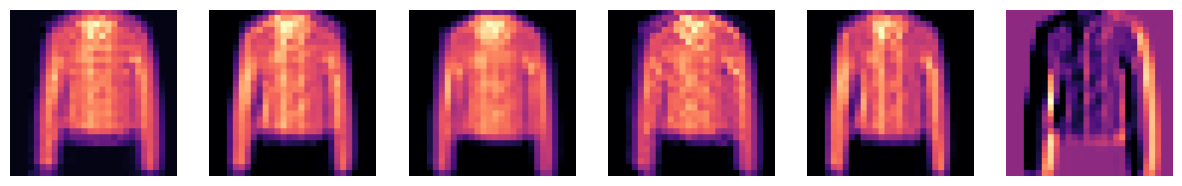

In [18]:
def visualize_pytorch(idx):
    img = x_test_p[idx:idx+1]
    model_p.eval()
    with torch.no_grad():
        activations = F.relu(model_p.conv1(img)).squeeze(0).numpy()

    fig, axes = plt.subplots(1, 6, figsize=(15, 3))
    for i in range(6):
        p_map = upscale_to_128x128(activations[i])
        axes[i].imshow(p_map, cmap='magma')
        axes[i].axis('off')
    plt.show()

visualize_pytorch(10)


In [19]:
_, acc_k = model_k.evaluate(x_test_k, y_test_raw, verbose=0)
model_p.eval()
with torch.no_grad():
    acc_p = (model_p(x_test_p).argmax(1) == y_test_p).float().mean().item()

print(f"Точность Keras:   {acc_k:.4f}")
print(f"Точность PyTorch: {acc_p:.4f}")

Точность Keras:   0.8786
Точность PyTorch: 0.8272
